In [2]:
import sys
from pathlib import Path

ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from src.data_loader import load_all_datasets
from src.preprocessing import add_rul_column
from src.config import DATASETS, USEFUL_SENSORS

sns.set_theme(style="whitegrid")
data = load_all_datasets()

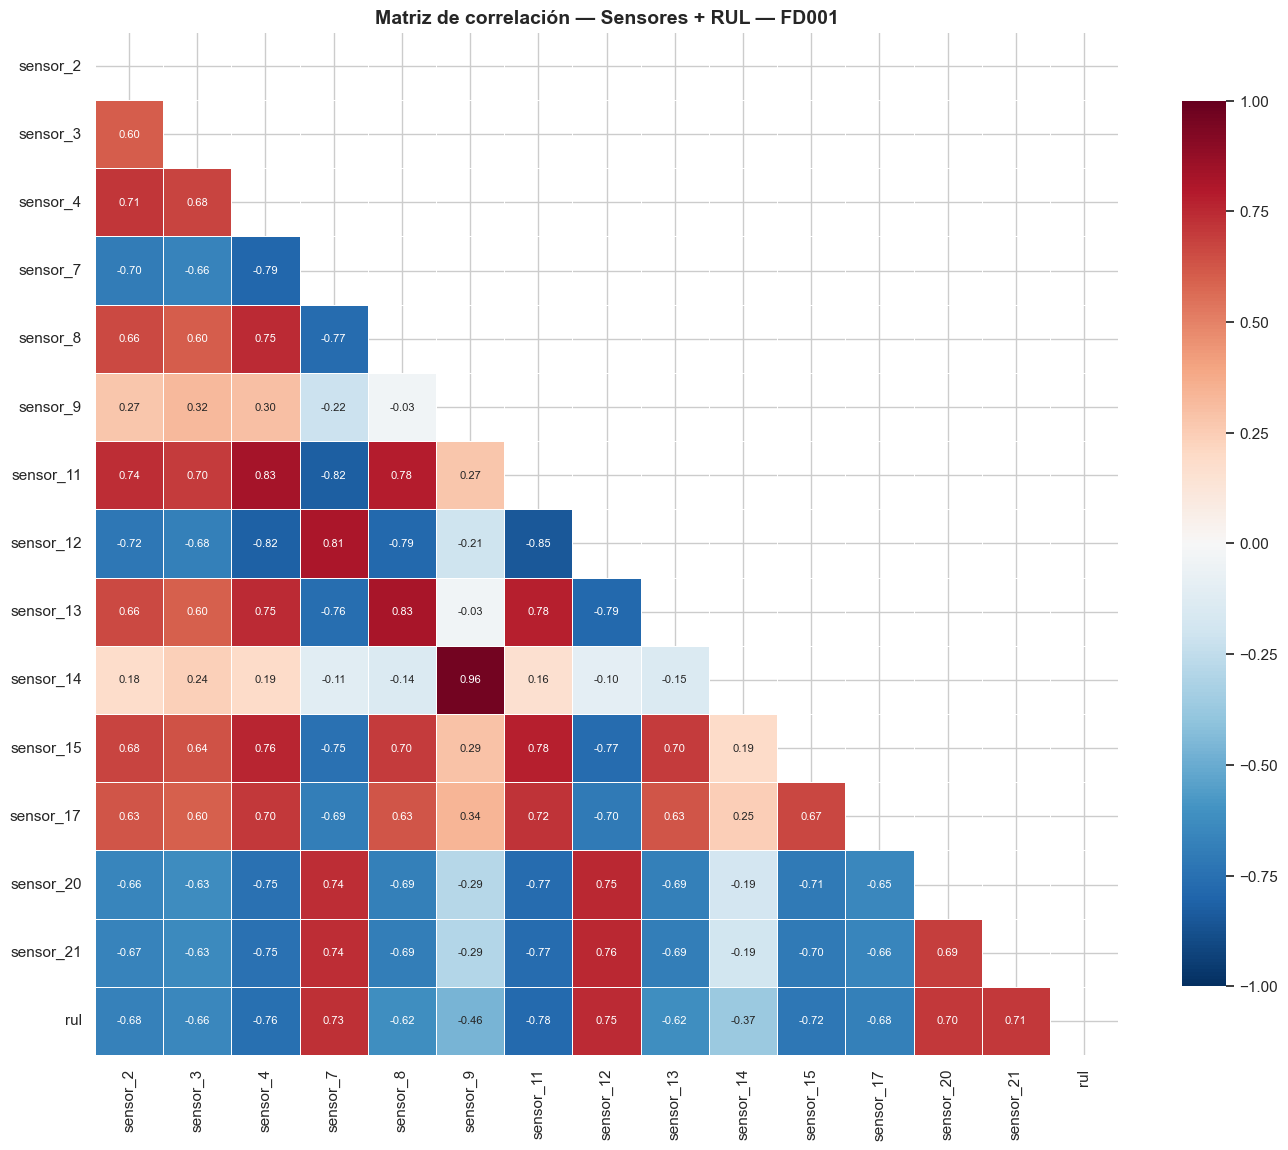

In [3]:
train = add_rul_column(data["FD001"][0])
corr = train[USEFUL_SENSORS + ["rul"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)
ax.set_title("Matriz de correlación — Sensores + RUL — FD001", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

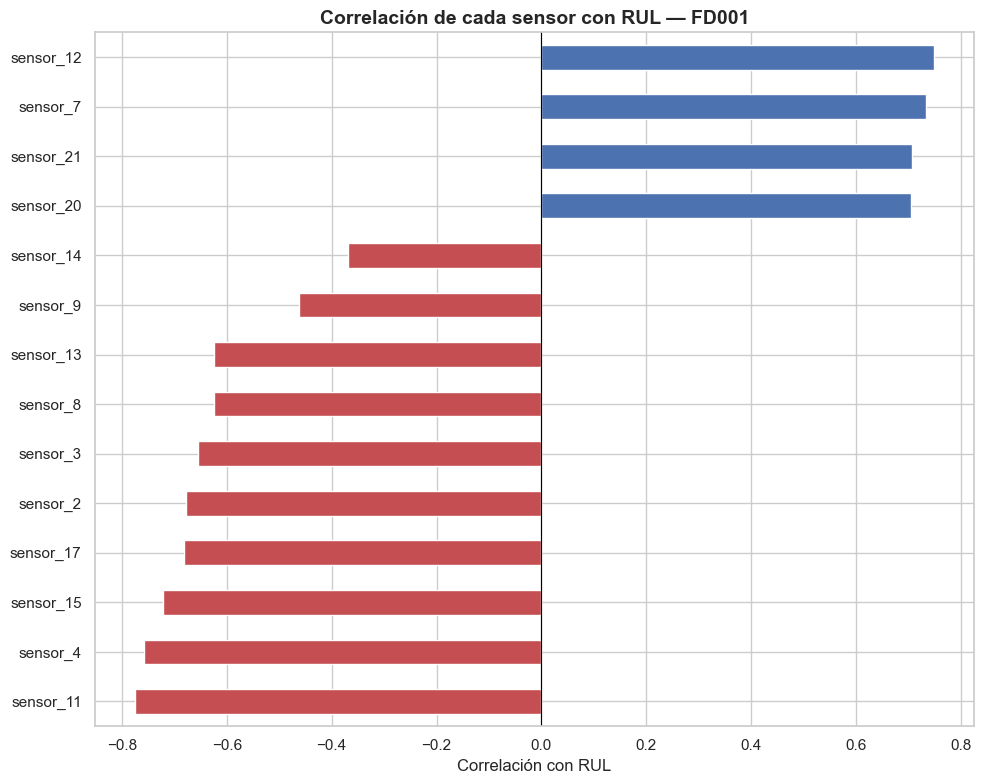

In [4]:
rul_corr = corr["rul"].drop("rul").sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in rul_corr.values]
rul_corr.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación con RUL")
ax.set_title("Correlación de cada sensor con RUL — FD001", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

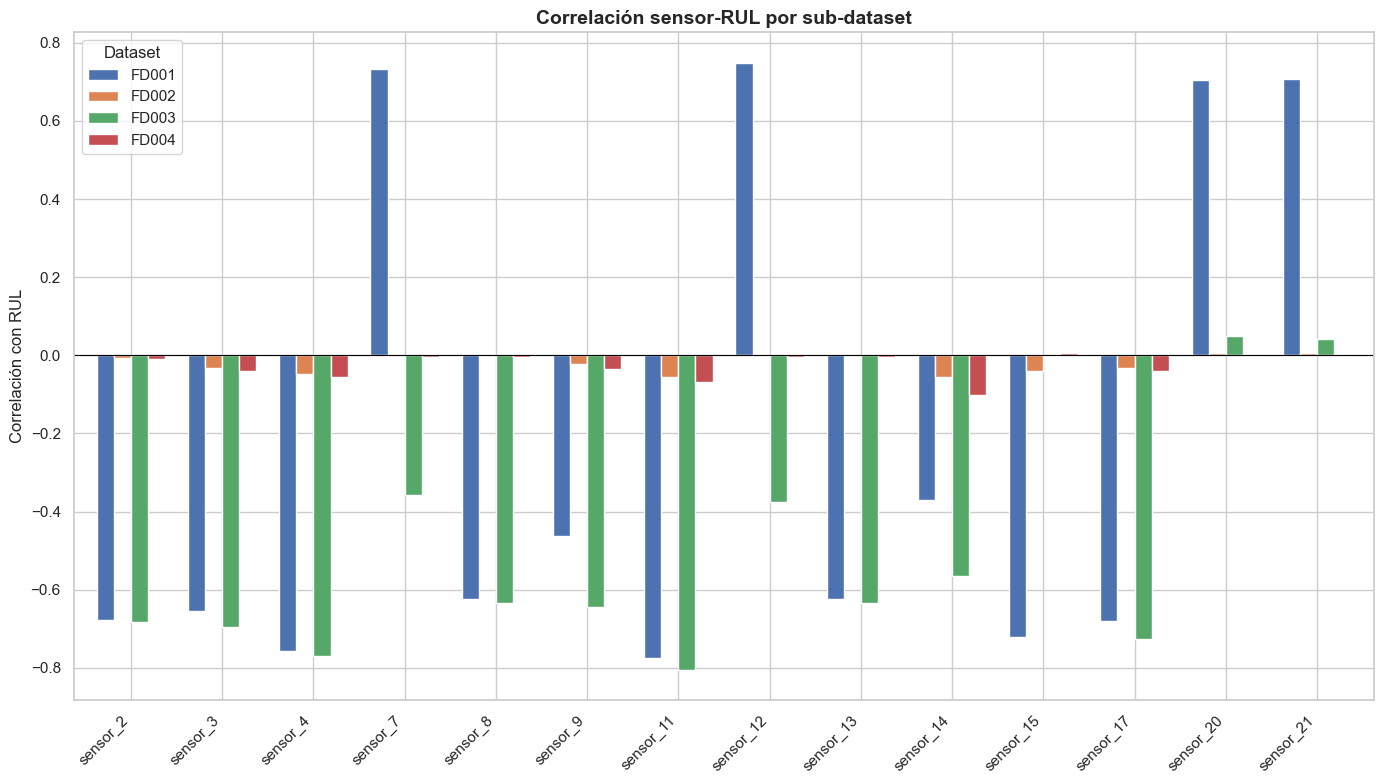

In [5]:
rul_corrs = {}
for ds_id in DATASETS:
    tr = add_rul_column(data[ds_id][0])
    available = [s for s in USEFUL_SENSORS if s in tr.columns]
    rul_corrs[ds_id] = tr[available + ["rul"]].corr()["rul"].drop("rul")

rul_corr_df = pd.DataFrame(rul_corrs)

fig, ax = plt.subplots(figsize=(14, 8))
rul_corr_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Correlación con RUL")
ax.set_title("Correlación sensor-RUL por sub-dataset", fontsize=14, fontweight="bold")
ax.legend(title="Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

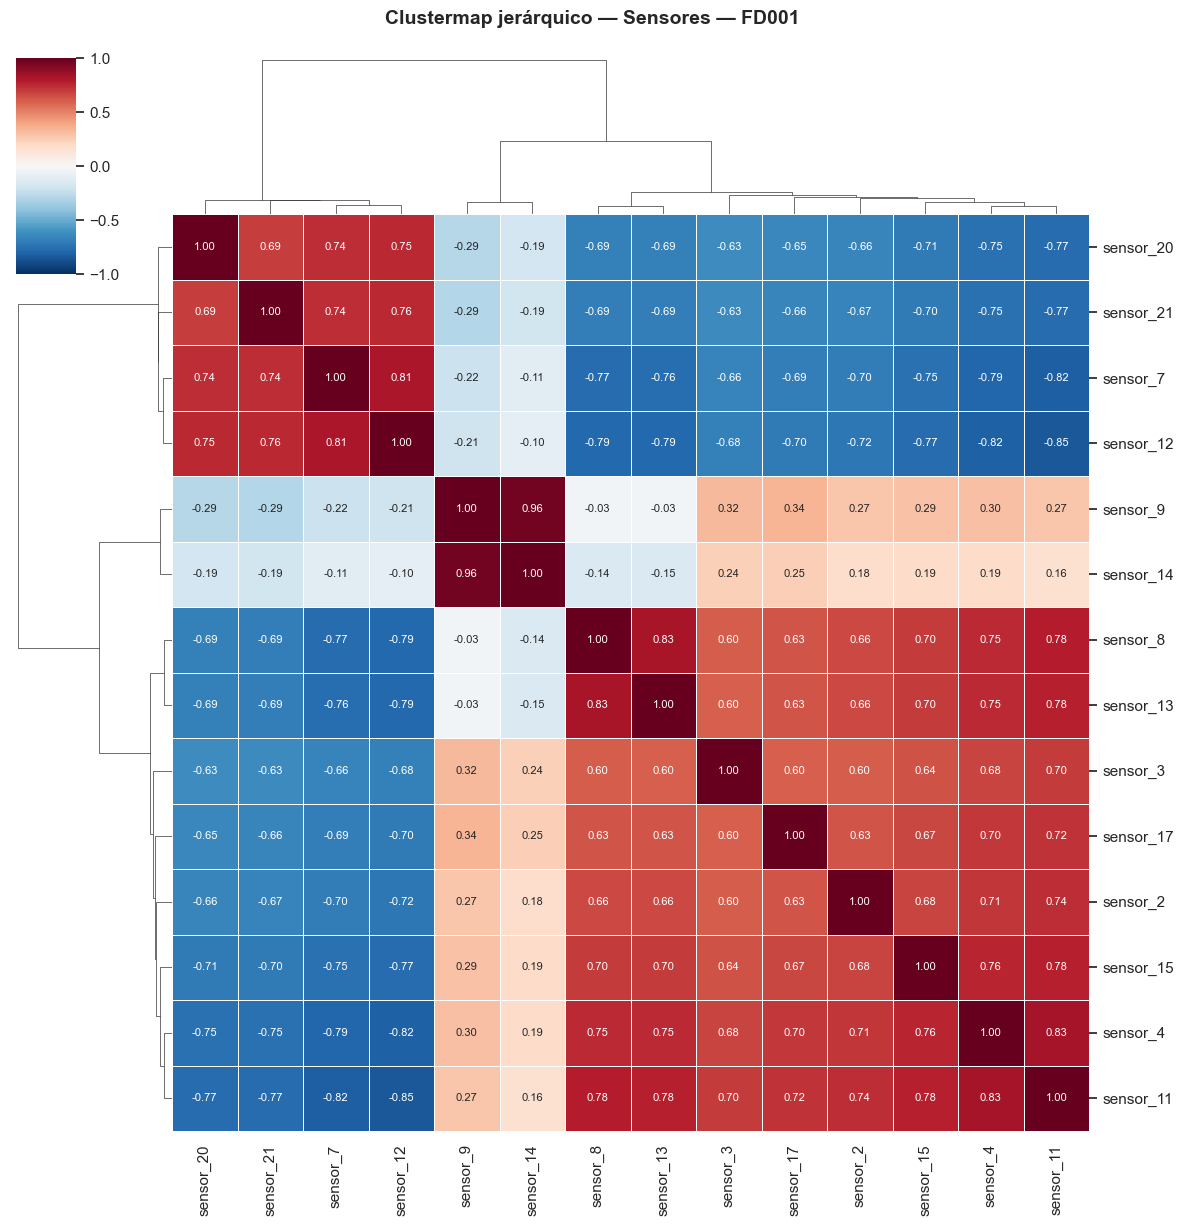

In [6]:
sensor_data = train[USEFUL_SENSORS]
corr_matrix = sensor_data.corr()

g = sns.clustermap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    figsize=(12, 12),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    dendrogram_ratio=(0.15, 0.15),
)
g.fig.suptitle("Clustermap jerárquico — Sensores — FD001", fontsize=14, fontweight="bold", y=1.02)
plt.show()

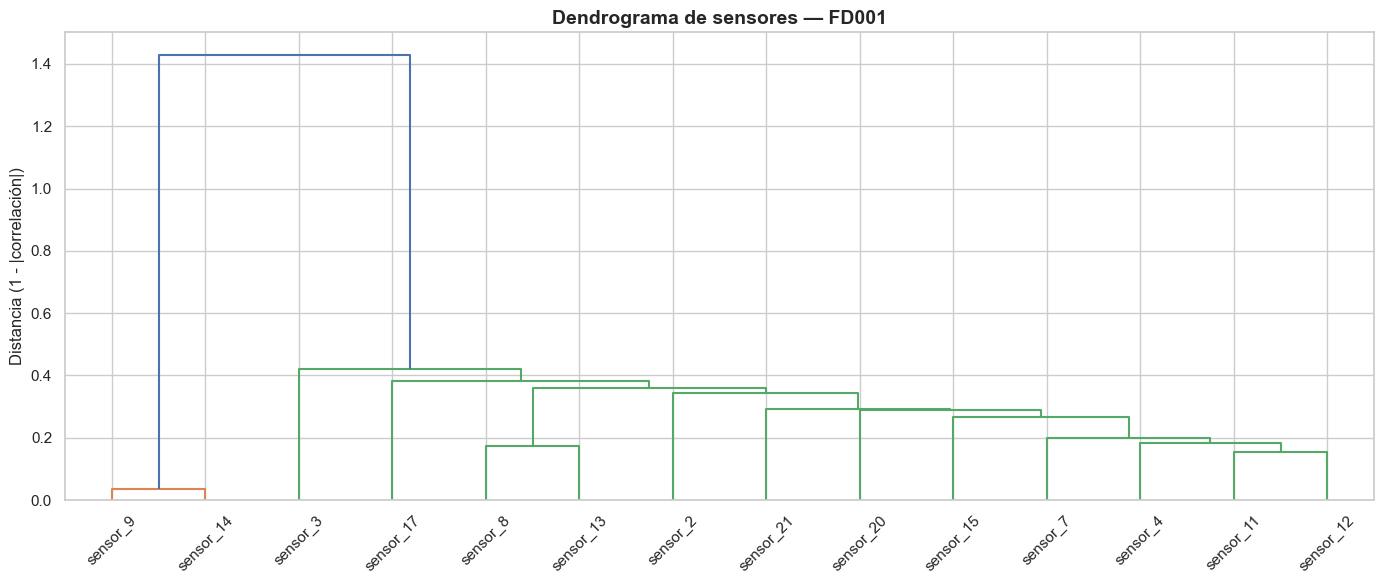

In [7]:
corr_distance = 1 - corr_matrix.abs()
dist_array = squareform(corr_distance.values)
linkage_matrix = linkage(dist_array, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    labels=corr_matrix.columns.tolist(),
    leaf_rotation=45,
    leaf_font_size=11,
    ax=ax,
    color_threshold=0.7,
)
ax.set_ylabel("Distancia (1 - |correlación|)")
ax.set_title("Dendrograma de sensores — FD001", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

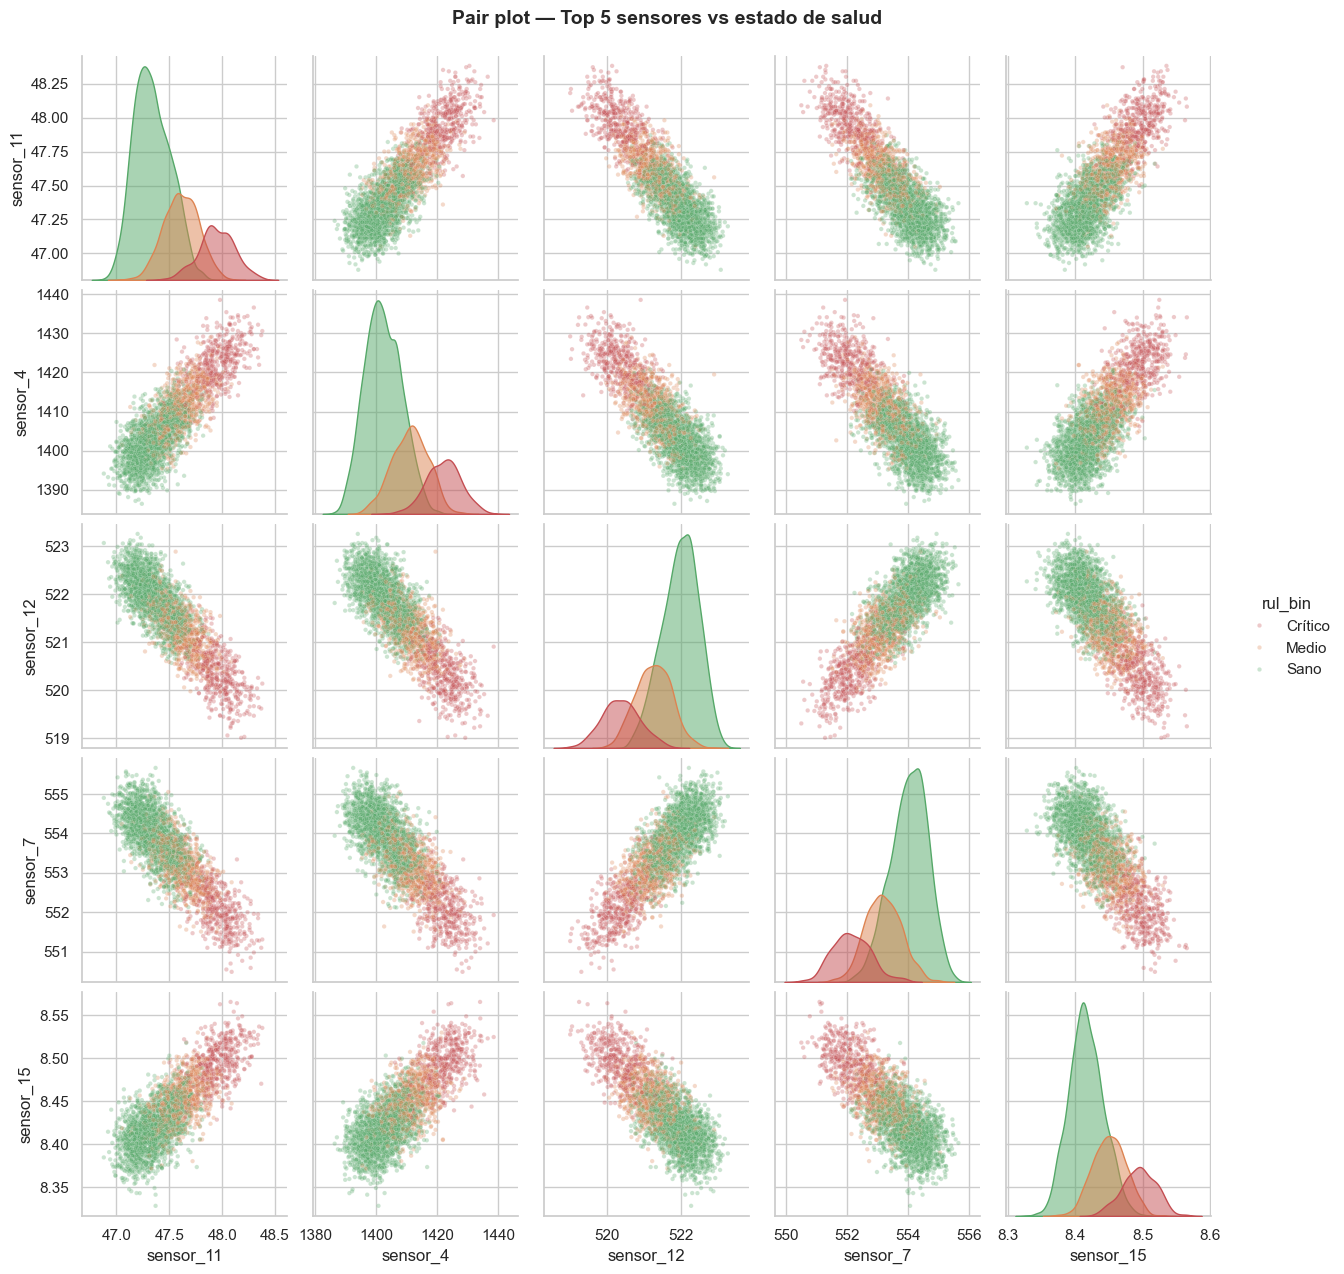

In [8]:
top5 = rul_corr.abs().sort_values(ascending=False).head(5).index.tolist()

sample = train[train["unit_id"].isin(train["unit_id"].unique()[:15])].copy()
sample["rul_bin"] = pd.cut(sample["rul"], bins=[0, 30, 80, 125], labels=["Crítico", "Medio", "Sano"])

g = sns.pairplot(
    sample[top5 + ["rul_bin"]],
    hue="rul_bin",
    palette={"Crítico": "#C44E52", "Medio": "#DD8452", "Sano": "#55A868"},
    plot_kws={"alpha": 0.3, "s": 10},
    diag_kws={"alpha": 0.5},
    height=2.5,
)
g.fig.suptitle("Pair plot — Top 5 sensores vs estado de salud", fontsize=14, fontweight="bold", y=1.02)
plt.show()

In [9]:
fig = px.imshow(
    corr.values,
    x=corr.columns.tolist(),
    y=corr.index.tolist(),
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlación interactiva — Sensores + RUL — FD001",
    height=700,
    width=800,
)
fig.update_layout(template="plotly_white")
fig.show()

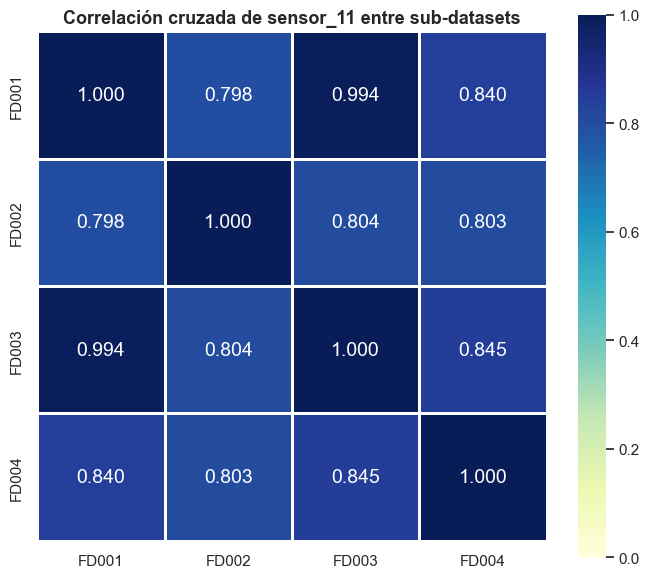

In [10]:
sensor = "sensor_11"

cross_data = {}
for ds_id in DATASETS:
    tr = add_rul_column(data[ds_id][0])
    mean_by_pct = tr.copy()
    mean_by_pct["life_pct"] = tr.groupby("unit_id")["cycle"].transform(lambda x: (x / x.max() * 100).round(0))
    cross_data[ds_id] = mean_by_pct.groupby("life_pct")[sensor].mean()

cross_df = pd.DataFrame(cross_data)
cross_corr = cross_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cross_corr,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    square=True,
    ax=ax,
    vmin=0,
    vmax=1,
    linewidths=1,
    annot_kws={"size": 14},
)
ax.set_title(f"Correlación cruzada de {sensor} entre sub-datasets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
top3 = rul_corr.abs().sort_values(ascending=False).head(3).index.tolist()
sample = train[train["unit_id"].isin(train["unit_id"].unique()[:20])]

fig = px.scatter_3d(
    sample,
    x=top3[0],
    y=top3[1],
    z=top3[2],
    color="rul",
    color_continuous_scale="RdYlGn",
    opacity=0.4,
    title=f"Espacio 3D — {top3[0]} × {top3[1]} × {top3[2]} — coloreado por RUL",
    height=700,
)
fig.update_traces(marker=dict(size=2.5))
fig.update_layout(template="plotly_white")
fig.show()

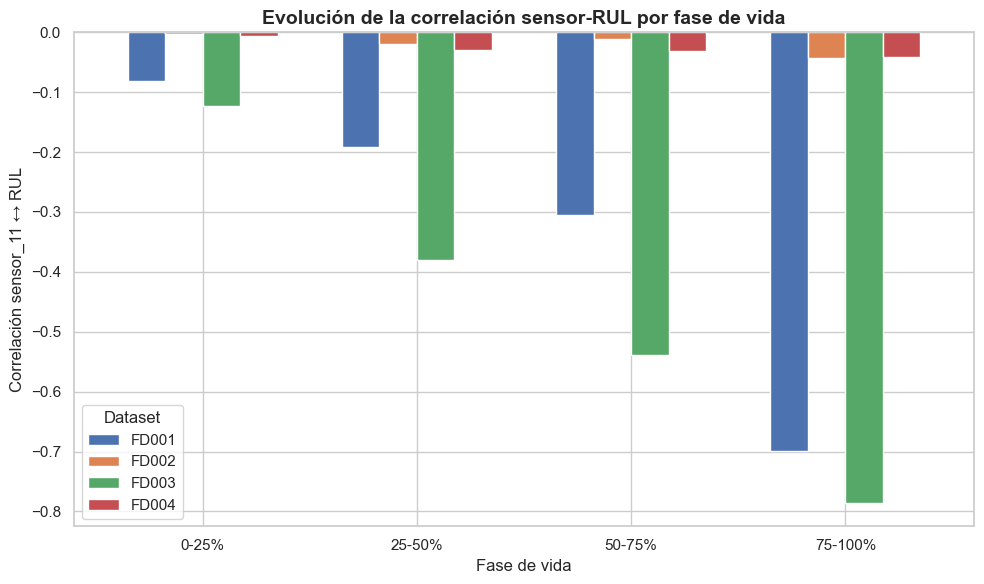

In [12]:
sensor = "sensor_11"
windows = [(0, 25), (25, 50), (50, 75), (75, 100)]
window_corrs = {}

for ds_id in DATASETS:
    tr = add_rul_column(data[ds_id][0])
    tr["life_pct"] = tr.groupby("unit_id")["cycle"].transform(lambda x: (x / x.max() * 100))
    corrs = []
    for lo, hi in windows:
        subset = tr[(tr["life_pct"] >= lo) & (tr["life_pct"] < hi)]
        if len(subset) > 10:
            corrs.append(subset[[sensor, "rul"]].corr().iloc[0, 1])
        else:
            corrs.append(np.nan)
    window_corrs[ds_id] = corrs

labels = [f"{lo}-{hi}%" for lo, hi in windows]
corr_temporal = pd.DataFrame(window_corrs, index=labels)

fig, ax = plt.subplots(figsize=(10, 6))
corr_temporal.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")
ax.set_ylabel(f"Correlación {sensor} ↔ RUL")
ax.set_xlabel("Fase de vida")
ax.set_title("Evolución de la correlación sensor-RUL por fase de vida", fontsize=14, fontweight="bold")
ax.legend(title="Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

sensor_data = train[USEFUL_SENSORS].dropna()
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(sensor_data), columns=USEFUL_SENSORS)

corr_abs = scaled.corr().abs()
upper = corr_abs.where(np.triu(np.ones_like(corr_abs, dtype=bool), k=1))
high_corr_pairs = [(col, row, corr_abs.loc[row, col]) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.9]
high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

print("Pares con correlación > 0.9:")
for s1, s2, val in high_corr_pairs:
    print(f"  {s1} ↔ {s2}: {val:.3f}")

Pares con correlación > 0.9:
  sensor_14 ↔ sensor_9: 0.963


In [14]:
print("=" * 60)
print("  RESUMEN CORRELACIONES")
print("=" * 60)
print(f"  Top 5 sensores correlacionados con RUL (FD001):")
for s in top5:
    print(f"    {s}: {rul_corr[s]:.3f}")
print(f"\n  Pares con alta multicolinealidad (>0.9): {len(high_corr_pairs)}")
print(f"  Clusters identificados en dendrograma: ~3-4 grupos")
print(f"  Correlación sensor-RUL se fortalece en fases finales")
print("=" * 60)

  RESUMEN CORRELACIONES
  Top 5 sensores correlacionados con RUL (FD001):
    sensor_11: -0.775
    sensor_4: -0.757
    sensor_12: 0.749
    sensor_7: 0.733
    sensor_15: -0.721

  Pares con alta multicolinealidad (>0.9): 1
  Clusters identificados en dendrograma: ~3-4 grupos
  Correlación sensor-RUL se fortalece en fases finales
